In [1]:
# Set some global parameters and paths
import os
import csv

DEBUG = True

BASE_DIR = os.path.abspath("")
ROOT_DIR = os.path.abspath(os.path.join(BASE_DIR, '../../'))
EXPERIMENTS_DIR = os.path.join(BASE_DIR, 'experiments')
RESULT_DIR = os.path.join(ROOT_DIR, 'results/lumi_mixer/cases')
OUTPUT_DIR = os.path.join(BASE_DIR, 'output')

if DEBUG:
    print("Base Directory:", BASE_DIR)
    print("Root Directory:", ROOT_DIR)
    print("Experiments Directory:", EXPERIMENTS_DIR)
    print("Data Directory:", RESULT_DIR)
    print("Output Directory:", OUTPUT_DIR)

Base Directory: /home/tife/Projects/neko-top/examples/lumi_mixer
Root Directory: /home/tife/Projects/neko-top
Experiments Directory: /home/tife/Projects/neko-top/examples/lumi_mixer/experiments
Data Directory: /home/tife/Projects/neko-top/results/lumi_mixer/cases
Output Directory: /home/tife/Projects/neko-top/examples/lumi_mixer/output


# Open an experiment, read the information there

Each experiment is a CSV file with headers reflecting the parameters used to
create the case files.

In [2]:
def read_experiment_file(file_path) -> list:
    """
    Read the experiment file and return a list of experiments with their
    parameters.

    Args:
        file_path (str): Path to the experiment CSV file.
    Returns:
        list: List of dictionaries, each representing an experiment with its
        parameters.
    """

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Experiment file not found: {file_path}")

    with open(os.path.join(file_path), 'r') as file:
        reader = csv.DictReader(file, delimiter=',', skipinitialspace=True)

        # Convert each row to a dictionary and store in a list
        tmp = [row for row in reader]

    experiments = []
    for row in tmp:
        experiment = {}
        for key, value in row.items():
            try:
                experiment[key] = int(value)
            except ValueError:
                try:
                    experiment[key] = float(value)
                except ValueError:
                    if value.lower() in ['true', 'false']:
                        experiment[key] = value.lower() == 'true'
                    else:
                        experiment[key] = value

        # Check if the experiment has been completed and set the status
        if os.path.exists(os.path.join(RESULT_DIR, experiment['case_name'])):
            experiment['status'] = 'done'
        else:
            experiment['status'] = 'pending'

        experiments.append(experiment)

    return experiments


In [3]:
experiment_file = os.path.join(EXPERIMENTS_DIR, 'single_node_capacity.csv')
experiment = read_experiment_file(experiment_file)
if DEBUG:
    print(f"Loaded {len(experiment)} experiments.")
    for exp in experiment:
        print(exp)


Loaded 5 experiments.
{'case_name': 'lumi-g_nodes_1_mesh_8x2x2', 'cluster': 'LUMI-G', 'Nx': 8, 'Ny': 2, 'Nz': 2, 'nodes': 1, 'Np': 8, 'status': 'done'}
{'case_name': 'lumi-g_nodes_1_mesh_16x4x4', 'cluster': 'LUMI-G', 'Nx': 16, 'Ny': 4, 'Nz': 4, 'nodes': 1, 'Np': 8, 'status': 'done'}
{'case_name': 'lumi-g_nodes_1_mesh_32x8x8', 'cluster': 'LUMI-G', 'Nx': 32, 'Ny': 8, 'Nz': 8, 'nodes': 1, 'Np': 8, 'status': 'done'}
{'case_name': 'lumi-g_nodes_1_mesh_64x16x16', 'cluster': 'LUMI-G', 'Nx': 64, 'Ny': 16, 'Nz': 16, 'nodes': 1, 'Np': 8, 'status': 'done'}
{'case_name': 'lumi-g_nodes_1_mesh_128x32x32', 'cluster': 'LUMI-G', 'Nx': 128, 'Ny': 32, 'Nz': 32, 'nodes': 1, 'Np': 8, 'status': 'done'}


# Parse the log files to extract the performance metrics

In [4]:
def read_rt_stats_from_log(log_path: str) -> list:
    """
    Read the runtime statistics from the log file.

    Args:
        log_path (str): Path to the log file.
    Returns:
        list: List of dictionaries containing the runtime statistics.
    """

    if not os.path.exists(log_path):
        raise FileNotFoundError(f"Log file not found: {log_path}")

    with open(log_path, 'r') as file:
        lines = file.readlines()

    # Look for the pattern
    # `------Runtime statistics------` followed by an empty line
    # Then read the following table until an empty line is found

    start_index = None
    for i, line in enumerate(lines):
        if '------Runtime statistics------' in line:
            start_index = i + 2  # Skip the next empty line
            break
    if start_index is None:
        raise ValueError("Runtime statistics section not found in log file.")

    end_index = start_index
    while end_index < len(lines) and lines[end_index].strip():
        end_index += 1

    # Extract the relevant lines
    stats_lines = lines[start_index:end_index]

    # Parse the statistics lines into a structured format
    header = ["Region name", "Total time", "Avg time", "Range +/-"]

    data = []
    for line in stats_lines[2:]:
        parts = line.strip().split()
        if len(parts) >= 4:
            region_name = " ".join(parts[:-3])
            total_time = float(parts[-3])
            avg_time = float(parts[-2])
            range_plus_minus = float(parts[-1])
            data.append({
                header[0]: region_name,
                header[1]: total_time,
                header[2]: avg_time,
                header[3]: range_plus_minus
            })
    return data


In [5]:
# Parse the log files to extract the performance metrics
exp = experiment[0]  # Example: process the first experiment
log_file = os.path.join(RESULT_DIR, exp['case_name'],
                        exp['case_name'] + '.log')
data = read_rt_stats_from_log(log_file)
if DEBUG:
    print("Parsed Statistics Data:")
    for row in data:
        print(row)


Parsed Statistics Data:
{'Region name': 'Fluid', 'Total time': 18.01163, 'Avg time': 0.04502908, 'Range +/-': 0.1039332}
{'Region name': 's', 'Total time': 0.3350198, 'Avg time': 0.0008375495, 'Range +/-': 3.595745e-05}
{'Region name': 'Pressure_solve', 'Total time': 16.17995, 'Avg time': 0.04044988, 'Range +/-': 0.08386919}
{'Region name': 'Velocity_solve', 'Total time': 0.6551958, 'Avg time': 0.001637989, 'Range +/-': 0.0001375277}
{'Region name': 'gather_scatter', 'Total time': 5.646257, 'Avg time': 6.690195e-05, 'Range +/-': 3.349194e-06}
{'Region name': 'HSMG_solve', 'Total time': 15.0289, 'Avg time': 0.00439956, 'Range +/-': 0.002912294}
{'Region name': 'HSMG_schwarz', 'Total time': 1.922696, 'Avg time': 0.0005628502, 'Range +/-': 4.76653e-05}
{'Region name': 'HSMG_coarse_grid', 'Total time': 12.35148, 'Avg time': 0.003615772, 'Range +/-': 0.001967065}
{'Region name': 'HSMG_coarse_solve', 'Total time': 12.13019, 'Avg time': 0.003550993, 'Range +/-': 0.001897214}
{'Region name': '

Number of Elements: [32, 256, 2048, 16384, 131072]
Timestep Times: [0.04613394, 0.172897, 0.08083756, 0.2758761, 2.500547]
Adjoint Timestep Times: [0.005206884, 0.1074682, 0.4385127, 0.5294648, 5.097409]
Checkpoint Save Times: [6.543366e-05, 0.0003264513, None, None, None]
Checkpoint Restore Times: [0.04428043, 0.1883113, None, None, None]


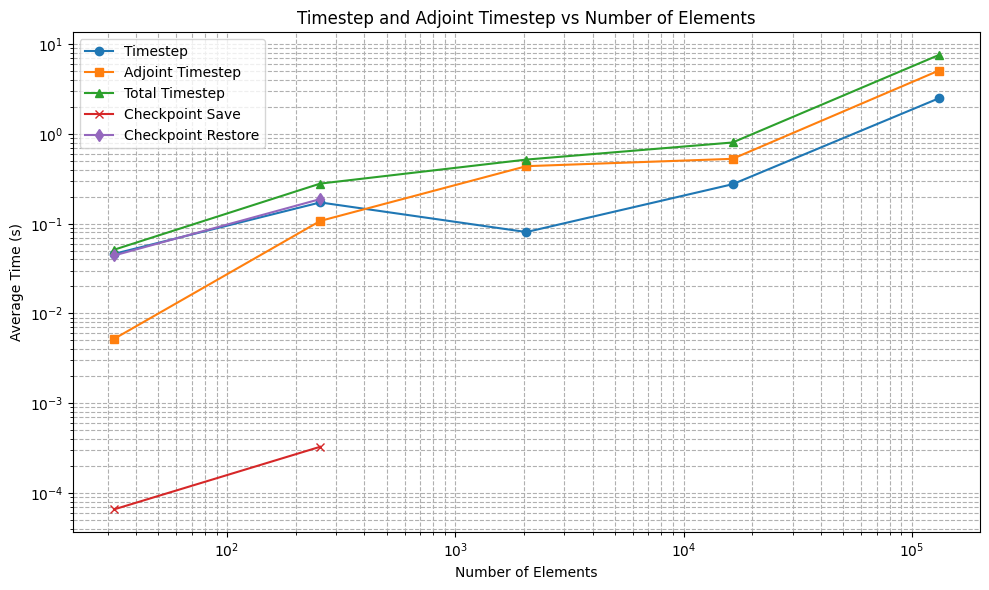

In [8]:
# Plot the timestep and adjoint timestep as a function of the number of elements

import matplotlib.pyplot as plt
import numpy as np

# Example data for plotting
for exp in experiment:
    log_file = os.path.join(RESULT_DIR, exp['case_name'],
                            exp['case_name'] + '.log')
    data = read_rt_stats_from_log(log_file)
    exp['timestep'] = next(
        (d['Avg time'] for d in data if d['Region name'] == 'Time-Step'), None)
    exp['adjoint_timestep'] = next(
        (d['Avg time']
         for d in data if d['Region name'] == 'Time-Step Adjoint'), None)
    exp['checkpoint_save'] = next(
        (d['Avg time'] for d in data if d['Region name'] == 'Checkpoint save'),
        None)
    exp['checkpoint_restore'] = next(
        (d['Avg time']
         for d in data if d['Region name'] == 'Checkpoint restore'), None)

num_elements = [exp['Nx'] * exp['Ny'] * exp['Nz'] for exp in experiment]
timestep = [exp['timestep'] for exp in experiment]
adjoint_timestep = [exp['adjoint_timestep'] for exp in experiment]
checkpoint_save = [exp['checkpoint_save'] for exp in experiment]
checkpoint_restore = [exp['checkpoint_restore'] for exp in experiment]

if DEBUG:
    print("Number of Elements:", num_elements)
    print("Timestep Times:", timestep)
    print("Adjoint Timestep Times:", adjoint_timestep)
    print("Checkpoint Save Times:", checkpoint_save)
    print("Checkpoint Restore Times:", checkpoint_restore)

plt.figure(figsize=(10, 6))
plt.plot(num_elements, timestep, marker='o', label='Timestep')
plt.plot(num_elements, adjoint_timestep, marker='s', label='Adjoint Timestep')
plt.plot(num_elements, [t + a for t, a in zip(timestep, adjoint_timestep)],
         marker='^',
         label='Total Timestep')
plt.plot(num_elements, checkpoint_save, marker='x', label='Checkpoint Save')
plt.plot(num_elements,
         checkpoint_restore,
         marker='d',
         label='Checkpoint Restore')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Elements')
plt.ylabel('Average Time (s)')
plt.title('Timestep and Adjoint Timestep vs Number of Elements')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.tight_layout()